In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path

# 1 - Load and Clean Data

In [2]:
def load_and_clean(csv_path):
    df = pd.read_csv(csv_path)
    return df

# 2 - Estimate Parameters

In [3]:
def estimate_parameters(df):
    returns = np.log(df["Close"]).diff().dropna()
    
    # Compute sigma
    sigma = returns.std()
    avg_price = df["Close"].mean()
    sigma = sigma * avg_price

    # Compute epsilon
    epsilon = 0.0001 * avg_price

    # Compute eta 
    avg_volume = df["Volume"].mean()
    eta = epsilon / (0.01 * avg_volume)

    # Compute gamma
    gamma = epsilon / (0.1 * avg_volume)
    
    return {
        'sigma': sigma,
        'gamma': gamma,
        'eta': eta,
        'epsilon': epsilon
    }

# 3 - Almgren-Chriss Model

## Almgren–Chriss Strategy Function

This function computes a **single-asset Almgren–Chriss liquidation strategy** under the **linear impact model**.

It takes in:
- `lam`: risk-aversion parameter
- `choice_params`: dictionary containing `X`, `T`, and `N`
- `stock_params`: dictionary containing `sigma`, `gamma`, `eta`, and `epsilon`

---

### Step 1: Extract input parameters

From `choice_params`:
- $X$: Ininital portfolio position we want to liquidate
- $T$: Total liquidation horizon
- $N$: Number of discrete trading periods

From `stock_params`:
- $\sigma$: Volatility parameter
- $\gamma$: permanent impact coefficient
- $\eta$: temporary impact coefficient
- $\epsilon$: Fixed temporary impact term (i.e. half spread).

---

### Step 2: Compute the time step

The code computes the time step as

$$
\tau = \frac{T}{N}.
$$

It also creates the discrete time grid

$$
t_k = 0, \tau, 2\tau, \dots, T.
$$

In code, this is done with:

```python
tau = T / N
t_k = np.linspace(0.0, T, N+1)
```

---

### Step 3: Compute the adjusted temporary impact parameter

The code next computes the adjusted temporary impact parameter

$$
\tilde{\eta} = \eta - \frac{1}{2}\gamma \tau
$$

In code:

```python
eta_tilde = eta - 0.5 * gamma * tau
```

---

### Step 4: Compute the liquidation speed parameter

The liquidation speed parameter is

$$
\kappa = \sqrt{\frac{\lambda \sigma^2}{\tilde{\eta}}}
$$

In code:

```python
kappa = np.sqrt((lam * sigma**2) / eta_tilde)
```

Interpretation:
- Larger $\lambda$ → more risk-averse → faster liquidation  
- Larger $\sigma$ → more volatility → faster liquidation  
- Larger $\tilde{\eta}$ → higher trading cost → slower liquidation  

---

### Step 5: Compute the optimal holdings path

Using Equation (17), the optimal number of shares remaining at each time is

$$
x_k = \frac{X \sinh\big(\kappa (T - t_k)\big)}{\sinh(\kappa T)}
$$

In code:

```python
x = (X * np.sinh(kappa * (T - t_k))) / (np.sinh(kappa * T))
```

We enforce the endpoints:

```python
x[0] = X
x[-1] = 0
```

So the strategy starts with full inventory and ends fully liquidated:

$$
x_0 = X, \quad x_N = 0
$$

---

### Step 6: Compute the trade list

The number of shares sold in each period is

$$
n_k = x_{k-1} - x_k
$$

In code:

```python
n_k = x[:-1] - x[1:]
```

This converts the holdings path into actual trades.

---

### Step 7: Compute expected implementation shortfall

The expected cost of executing the strategy is

$$
E(x) = \frac{1}{2}\gamma X^2
+ \epsilon \sum_{k=1}^{N} |n_k|
+ \frac{\tilde{\eta}}{\tau}\sum_{k=1}^{N} n_k^2
$$

In code:

```python
expected_shortfall = (0.5 * gamma * X**2) + (epsilon * np.sum(np.abs(n_k)) + (eta_tilde/tau) * np.sum(n_k**2))
```

This represents the **average execution cost**.

---

### Step 8: Compute variance of shortfall

The variance of execution cost is

$$
V(x) = \sigma^2 \sum_{k=1}^{N} \tau x_k^2
$$

In code:

```python
variance_shortfall = (sigma**2) * np.sum(tau * x[1:]**2)
```

This measures the **risk (uncertainty)** due to price volatility while holding inventory.

---

### Step 9: Compute the objective function

The total objective is

$$
E(x) + \lambda V(x)
$$

In code:

```python
objective = expected_shortfall + lam * variance_shortfall
```

This balances cost and risk.

---

### Step 10: Return the results

The function returns:

```python
{
    "tau": tau,
    "kappa": kappa,
    "x": x,
    "n": n,
    "expected_shortfall": expected_shortfall,
    "variance_shortfall": variance_shortfall,
    "objective": objective
}
```

These outputs will allow us to analyze:
- our optimal liquidation path
- our trading schedule
- our cost vs risk tradeoff

In [4]:
# Calculate Expected Implementation Shortfall + Expected Variance + Optional Execution Strategy based on Risk Aversion (lambda)

# We'll use this to build an efficient frontier

def almgren_chriss_strategy(lam, choice_params, stock_params):
    # Step 1
    lam=lam
    X=choice_params['X']
    T=choice_params['T']
    N=choice_params['N']
    S0=stock_params["S0"] = 50
    sigma=stock_params['sigma']
    gamma=stock_params['gamma']
    eta=stock_params['eta']
    epsilon=stock_params['epsilon']

    if N <= 0:
        raise ValueError("N must be positive.")
    if T <= 0:
        raise ValueError("T must be positive.")
    if eta <= 0:
        raise ValueError("eta must be positive.")
    if sigma < 0:
        raise ValueError("sigma must be nonnegative.")
    if lam < 0:
        raise ValueError("lam should be nonnegative for standard AC execution.")
    
    # Step 2    
    tau = T / N
    t_k = np.linspace(0.0, T, N+1)

    # Step 3
    eta_tilde = eta - 0.5 * gamma * tau
    if eta_tilde <= 0:
        raise ValueError("Eta_tilde <= 0. Choose eta s.t. eta > 0.5 * gamma * tau")
    
    # Step 4
    #kappa = np.sqrt((lam * sigma**2) / eta_tilde)
    kappa_tilde_sq = (lam * sigma**2) / eta_tilde

    # (1 / tau) * arccosh(1 + tau^2 * 0.5 * kappa_tilde_sq)
    kappa = np.arccosh(1 + 0.5 * tau**2 * kappa_tilde_sq) / tau

    # Step 5
    x = (X * np.sinh(kappa * (T - t_k))) / (np.sinh(kappa * T))
    x[0] = X
    x[-1] = 0

    # Step 6
    n_k = x[:-1] - x[1:]

    # Step 7
    expected_shortfall = (0.5 * gamma * X**2) + (epsilon * np.sum(np.abs(n_k)) + (eta_tilde/tau) * np.sum(n_k**2))

    # Step 8
    variance_shortfall = (sigma**2) * np.sum(tau * x[1:]**2)

    # Step 9
    objective = expected_shortfall + lam * variance_shortfall

    # Step 10
    return {
        "tau": tau,
        "kappa": kappa,
        "x": x,
        "n_k": n_k,
        "expected_shortfall": expected_shortfall,
        "variance_shortfall": variance_shortfall,
        "objective": objective
    }



## Example (paper 3.4):

In [5]:
lam = 1e-6

chosen_parameters = { #paper example, but will be chosen by us prior
    'X':1_000_000, 
    'T':5, 
    'N':5, 
}

#stock_parameters = estimate_parameters(csv) #placeholder
stock_parameters = { #paper example
    'sigma':0.95, 
    'gamma':2.5e-7, 
    'eta':2.5e-6,
    'epsilon':0.0625
}

output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)
print(f"kappa                   = {output["kappa"]}")
print(f"holdings (x)            = {output["x"]}")
print(f"trades (n)              = {output["n_k"]}")
print(f"Expected shortfall      = {output["expected_shortfall"]}")
print(f"Shortfall root variance = {output["variance_shortfall"]}")
print(f"Objective: E + lam*V    = {output["objective"]}")

kappa                   = 0.6070761632470627
holdings (x)            = [1000000.          541955.55437392  289854.21940994  147897.48782172
   62141.80160577       0.        ]
trades (n)              = [458044.44562608 252101.33496399 141956.73158821  85755.68621596
  62141.80160577]
Expected shortfall      = 911226.9863037935
Shortfall root variance = 364128572058.141
Objective: E + lam*V    = 1275355.5583619345


## Efficient Frontier Construction

In this section, we construct the **efficient frontier** by evaluating the Almgren–Chriss strategy over a range of risk-aversion parameters $\lambda$.

---

### Step 1: Generate multiple $\lambda$ values

We generate a range of $\lambda$ values using:

```python
lambdas = np.logspace(-8, -4, 30)
```

This creates 30 values of $\lambda$ between $10^{-8}$ and $10^{-4}$, spaced logarithmically.

Interpretation:
- Small $\lambda$ → almost risk-neutral 
- Large $\lambda$ → highly risk-averse 

---

### Step 2: Compute $(E, V)$ for each $\lambda$

For each $\lambda$, we compute:

- Expected shortfall:
$$
E(x)
$$

- Variance of shortfall:
$$
V(x)
$$

using the Almgren–Chriss strategy:

```python
for lam in lambdas:
    output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)
    E_list.append(output["expected_shortfall"])
    V_list.append(output["variance_shortfall"])
```

This produces a set of points:

$$
(V(x), E(x))
$$

Each point corresponds to a different optimal strategy.

---

### Step 3: Construct the efficient frontier

The efficient frontier is the curve formed by plotting:

- x-axis: variance $V(x)$
- y-axis: expected cost $E(x)$

```python
plt.plot(V_vals, E_vals)
plt.scatter(V_vals, E_vals)
```

This curve represents the **optimal trade-off between cost and risk**.

---

### Step 4: Select a specific $\lambda$ (tangent portfolio)

We choose a specific $\lambda$ value (`lam`) and compute:

```python
output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)
E_star = output["expected_shortfall"]
V_star = output["variance_shortfall"]
U_star = E_star + lam * V_star
```

This gives a single optimal point on the frontier:

$$
(E^*, V^*)
$$

---

### Step 5: Plot the tangent line

The objective function is:

$$
U(x) = E(x) + \lambda V(x)
$$

Rewriting:

$$
E(x) = -\lambda V(x) + U
$$

This is a straight line with slope $-\lambda$.

In code:

```python
V_line = np.linspace(min(V_vals), max(V_vals), 100)
E_line = -lam * V_line + U_star
```

This line is tangent to the efficient frontier at $(V^*, E^*)$.

---

### Step 6: Final plot

We visualize:

- Efficient frontier (curve)
- Individual $(V, E)$ points
- Tangent line
- Optimal point $(V^*, E^*)$

```python
plt.plot(V_vals, E_vals)
plt.scatter(V_vals, E_vals)

plt.plot(V_line, E_line, color='orange', linestyle="--", label=f'lambda={lam}')
plt.scatter(V_star, E_star, color='red')
```

In [6]:
# Step 2
def efficient_frontier(lam_star, lambdas, chosen_parameters, stock_parameters):
    E_list=[]
    V_list=[]

    for lam in lambdas:
        output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)
        E_list.append(output["expected_shortfall"])
        V_list.append(output["variance_shortfall"])

    return E_list, V_list

In [7]:
# Step 1
lambdas = np.logspace(-8, -4, 30)

# Step 2
E_vals, V_vals= efficient_frontier(lam, lambdas, chosen_parameters, stock_parameters)

# Step 4
output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters) 
E_star = output["expected_shortfall"]
V_star = output["variance_shortfall"]
U_star = E_star + lam * V_star

# Step 5
V_line = np.linspace(min(V_vals), max(V_vals), 100)
E_line = -lam * V_line + U_star

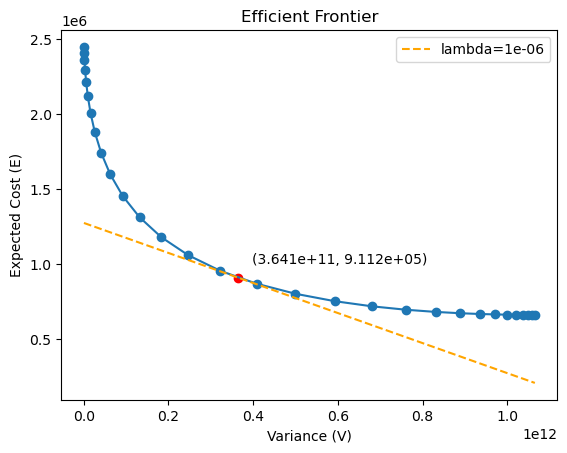

In [8]:
# Step 3
plt.plot(V_vals, E_vals)
plt.scatter(V_vals, E_vals)

# Step 6
plt.plot(V_line, E_line, color = 'orange', linestyle="--", label=f'lambda={lam}')
plt.scatter(V_star,E_star, color = 'red')
plt.annotate(f"({V_star:0.3e}, {E_star:0.3e})", (V_star, E_star),
    textcoords="offset points",
    xytext=(10,10))

plt.xlabel("Variance (V)")
plt.ylabel("Expected Cost (E)")
plt.title("Efficient Frontier")
plt.legend()
plt.show()

### Interpretation

- Each point on the curve represents an **optimal execution strategy**
- Moving along the curve changes the balance between:
  - Expected cost $E(x)$
  - Risk $V(x)$
- The tangent point $(V^*, E^*)$ is the **optimal strategy for a given $\lambda$**

Key insight:

- Lower $\lambda$ → lower cost, higher risk (slow trading)
- Higher $\lambda$ → higher cost, lower risk (fast trading)

The efficient frontier summarizes the **cost-risk tradeoff in optimal execution**.

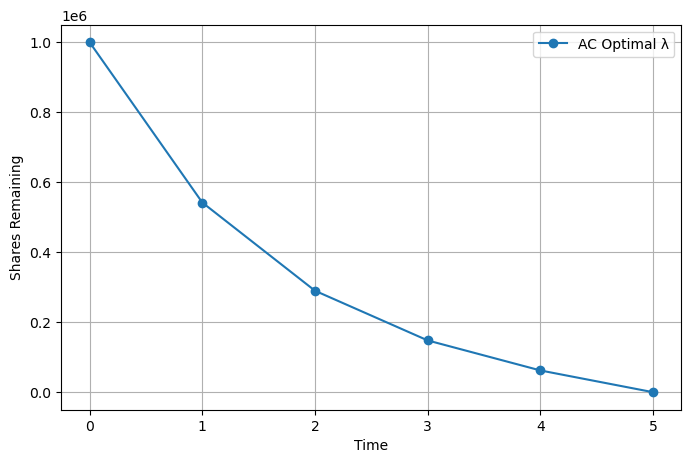

In [9]:
def trading_trajectories(lambdas, chosen_parameters, stock_parameters):
    trading_trajectories = []

    for lam in lambdas:
        output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)
        trading_trajectories.append(output["x"])

    return trading_trajectories

idx = [3, 15, -10]

holding_times = trading_trajectories(lambdas, chosen_parameters, stock_parameters)
times = np.linspace(0, chosen_parameters["T"], chosen_parameters["N"]+1)

plt.figure(figsize=(8,5))


plt.plot(times, holding_times[idx[0]], marker='o', label=f"TWAP")
plt.plot(times, output["x"], marker='o', label=f"AC Optimal λ")
plt.plot(times, holding_times[idx[2]], marker='o', label=f"λ={lambdas[idx[2]]:.1e}")

plt.title("")
plt.xlabel("Time")
plt.ylabel("Shares Remaining")
plt.legend()
plt.grid(True)
plt.show()

## Monte Carlo Simulation of Implementation Shortfall (AC vs TWAP)

After deriving the optimal execution strategy and constructing the efficient frontier analytically, we now implement a **Monte Carlo simulation** to validate the model in a stochastic setting.

The objective is to simulate the **realized implementation shortfall** under random price movements and compare it to the theoretical expected cost $E(x)$ and variance $V(x)$.

---

### 1. Price Dynamics

We simulate the asset price using the discrete-time process:

$$
S_k = S_{k-1} + \sigma \sqrt{\tau} \, \xi_k - \gamma n_k
$$

where:
- $(\sigma)$ is the volatility,
- $(\tau = T/N)$ is the time step,
- $(\xi_k \sim \mathcal{N}(0,1))$ are independent shocks,
- $(\gamma n_k)$ represents **permanent market impact**.

---

### 2. Execution Price

Trades are executed at prices adjusted for **temporary market impact**:

$$
\tilde{S}_k = S_{k-1} - \epsilon \cdot \text{sign}(n_k) - \eta \frac{n_k}{\tau}
$$

where:
- $(\epsilon)$ captures fixed costs (e.g., bid-ask spread),
- $(\eta)$ controls temporary impact,
- $(n_k)$ is the number of shares traded in period $(k)$.

---

### 3. Implementation Shortfall

The realized cost of execution is defined as:

$$
\text{Cost} = X S_0 - \sum_{k=1}^N n_k \tilde{S}_k
$$

This represents the difference between the initial portfolio value and the total execution revenue.

---

### 4. Simulation Procedure

The Monte Carlo simulation follows these steps:

1. Fix an optimal execution strategy $n_k$ from the Almgren–Chriss model.
2. Simulate price paths using random shocks $\xi_k$.
3. For each simulation:
   - compute execution prices $\tilde{S}_k$,
   - accumulate trading revenue,
   - calculate implementation shortfall.
4. Repeat for a large number of simulations (e.g., 10,000).
5. Compute:
   - the **empirical mean** of costs,
   - the **empirical variance**,
   - the full distribution of outcomes.

---

### 5. Interpretation

Under the model assumptions, implementation shortfall is approximately normally distributed:

$$
\text{Cost} \sim \mathcal{N}(E(x), V(x))
$$

The simulation allows us to verify that:
- the simulated mean aligns with \(E(x)\),
- the simulated variance aligns with \(V(x)\),
- the distribution is approximately Gaussian.

---

### 6. Key Insight

The Monte Carlo results illustrate the trade-off between **execution cost** and **risk**:

- Higher risk aversion $(\lambda)$ leads to faster execution, resulting in:
  - higher expected cost,
  - lower variance.

- Lower risk aversion leads to slower execution, resulting in:
  - lower expected cost,
  - higher exposure to price uncertainty.

Thus, Monte Carlo simulation complements the analytical framework by showing the **distribution of outcomes**, not just their expected values.

In [30]:
def monte_carlo_execution(lam, chosen_parameters, stock_parameters, n_sims=10000, seed=42):
    np.random.seed(seed)

    output = almgren_chriss_strategy(lam, chosen_parameters, stock_parameters)

    x = output["x"]
    n = x[:-1] - x[1:]

    X = chosen_parameters["X"]
    T = chosen_parameters["T"]
    N = chosen_parameters["N"]
    tau = T / N

    S0 = stock_parameters["S0"]
    sigma = stock_parameters["sigma"]
    gamma = stock_parameters["gamma"]
    eta = stock_parameters["eta"]
    epsilon = stock_parameters["epsilon"]

    costs = []

    for sim in range(n_sims):
        S = S0
        capture = 0

        for k in range(N):
            v = n[k] / tau

            # execution price with temporary impact
            execution_price = S - epsilon * np.sign(n[k]) - eta * v

            # revenue from selling n[k] shares
            capture += n[k] * execution_price

            # next market price with permanent impact
            xi = np.random.normal(0, 1)
            S = S + sigma * np.sqrt(tau) * xi - gamma * n[k]

        cost = X * S0 - capture
        costs.append(cost)

    costs = np.array(costs)

    results = {
        "lambda": lam,
        "simulated_costs": costs,
        "simulated_mean": np.mean(costs),
        "simulated_variance": np.var(costs, ddof=1),
        "theoretical_E": output["expected_shortfall"],
        "theoretical_V": output["variance_shortfall"]
    }

    return results

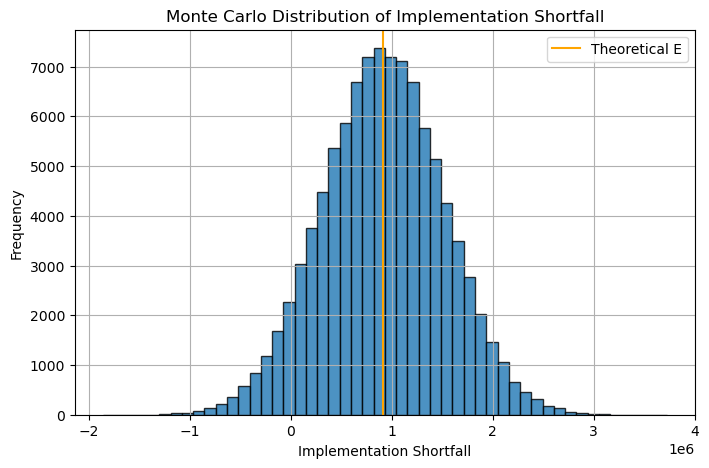

In [ ]:
mc_result = monte_carlo_execution(
    lam=1e-6,
    chosen_parameters=chosen_parameters,
    stock_parameters=stock_parameters,
    n_sims=100000
)

mc_result["simulated_mean"], mc_result["theoretical_E"]

plt.figure(figsize=(8,5))

plt.hist(mc_result["simulated_costs"], bins=50, edgecolor="black", alpha=0.8)

plt.axvline(mc_result["theoretical_E"], linestyle="-", color="orange", label="Theoretical Cost")

plt.title("Monte Carlo Distribution of Implementation Shortfall")
plt.xlabel("Implementation Shortfall")
plt.ylabel("Frequency")
plt.legend()
plt.show()

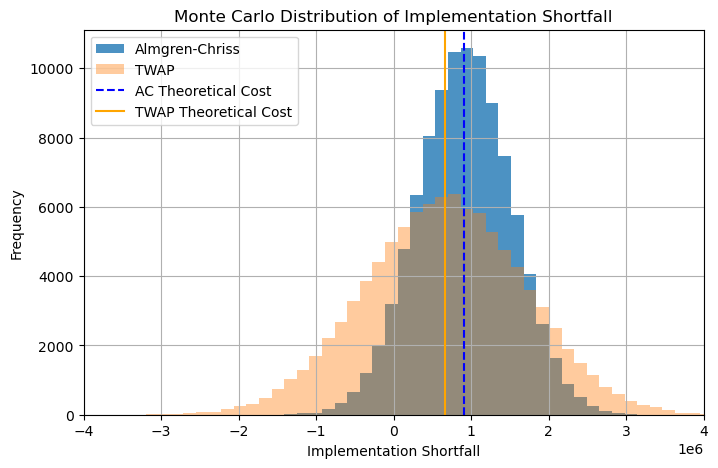

In [46]:
mc_TWAP = monte_carlo_execution(
    lam=1e-8,
    chosen_parameters=chosen_parameters,
    stock_parameters=stock_parameters,
    n_sims=100000
)

mc_AC = monte_carlo_execution(
    lam=1e-6,
    chosen_parameters=chosen_parameters,
    stock_parameters=stock_parameters,
    n_sims=100000
)


all_costs = np.concatenate([mc_TWAP["simulated_costs"], mc_AC["simulated_costs"]])
xmin, xmax = np.percentile(all_costs, [0, 99])
bins = np.linspace(np.min(all_costs), np.max(all_costs), 60)

plt.figure(figsize=(8,5))

plt.hist(mc_AC["simulated_costs"], bins=bins, alpha=0.8, label="Almgren-Chriss", density=False)
plt.hist(mc_TWAP["simulated_costs"], bins=bins, alpha=0.4, label="TWAP", density=False)

plt.axvline(mc_AC["theoretical_E"], linestyle="--", color="blue", label="AC Theoretical Cost")
plt.axvline(mc_TWAP["theoretical_E"], linestyle="-", color="orange", label="TWAP Theoretical Cost")

plt.title("Monte Carlo Distribution of Implementation Shortfall")
plt.xlabel("Implementation Shortfall")
plt.xlim(-4e6, 4e6)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

AC Optimal:
Mean: 912877.3017418135
Variance: 363775197155.7507
Theoretical E: 911226.9863037935
Theoretical V: 364128572058.141

TWAP / Naive:
Mean: 665683.4443964917
Variance: 1062325225074.382
Theoretical E: 662588.8435947369
Theoretical V: 1065146935248.5139


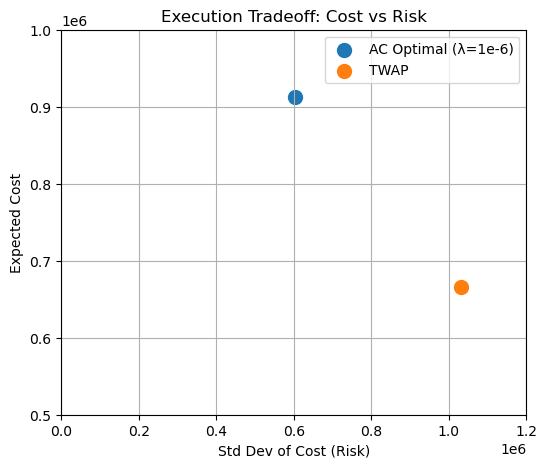

In [34]:
# AC optimal strategy from paper
mc_ac = monte_carlo_execution(
    lam=1e-6,
    chosen_parameters=chosen_parameters,
    stock_parameters=stock_parameters,
    n_sims=100000
)

# TWAP / naive strategy
# Since your function cannot take lambda = 0 directly, use the smallest lambda in your grid
mc_twap = monte_carlo_execution(
    lam=1e-8,
    chosen_parameters=chosen_parameters,
    stock_parameters=stock_parameters,
    n_sims=100000
)

print("AC Optimal:")
print("Mean:", mc_ac["simulated_mean"])
print("Variance:", mc_ac["simulated_variance"])
print("Theoretical E:", mc_ac["theoretical_E"])
print("Theoretical V:", mc_ac["theoretical_V"])

print("\nTWAP / Naive:")
print("Mean:", mc_twap["simulated_mean"])
print("Variance:", mc_twap["simulated_variance"])
print("Theoretical E:", mc_twap["theoretical_E"])
print("Theoretical V:", mc_twap["theoretical_V"])


plt.figure(figsize=(6,5))

# AC point
plt.scatter(
    np.sqrt(mc_ac["simulated_variance"]),
    mc_ac["simulated_mean"],
    label="AC Optimal (λ=1e-6)",
    s=100
)

# TWAP point
plt.scatter(
    np.sqrt(mc_twap["simulated_variance"]),
    mc_twap["simulated_mean"],
    label="TWAP",
    s=100
)

plt.xlim(0, 1_200_000)      # risk axis
plt.ylim(500_000, 1_000_000)  # cost axis
plt.xlabel("Std Dev of Cost (Risk)")
plt.ylabel("Expected Cost")
plt.title("Execution Tradeoff: Cost vs Risk")
plt.legend()
plt.grid(True)

plt.show()